# Aula 3 — Revisão de Álgebra Linear II
### Autovalores, autovetores, decomposição espectral, matrizes ortogonais e normas

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 3. A ideia é *ver* a matriz como uma
transformação e descobrir suas **direções invariantes** (autovetores) e os fatores de escala
associados (autovalores). Tratamos também de normas (vetoriais e matriciais), matrizes
ortogonais e da **decomposição espectral** de matrizes simétricas, que prepara diretamente a SVD
da próxima aula.

Todos os exemplos numéricos reproduzem os Exemplos 1–12 e o Exercício 5 das notas, para que você
confira o resultado computacional contra o resultado feito à mão.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | autovalores (`eig`/`eigh`), normas, determinante, posto |
| `matplotlib` | 3.5 | visualizações 2D |

```bash
pip install numpy matplotlib
```

> Nenhuma biblioteca opcional é necessária nesta aula.

In [1]:
# --- Imports concentrados ---
import numpy as np                 # vetores, matrizes, autovalores, normas
import matplotlib.pyplot as plt    # gráficos 2D

print("Ambiente pronto.")

Ambiente pronto.


## Objetivos computacionais

1. Calcular produto interno, normas $\ell_1,\ell_2,\ell_\infty$, ortogonalidade e normalização.
2. Verificar que matrizes **ortogonais** preservam norma e ângulo ($Q^{-1}=Q^T$).
3. Calcular **autovalores/autovetores** e visualizar direções invariantes.
4. Verificar **diagonalização** $A=V\Lambda V^{-1}$, potências $A^k=V\Lambda^kV^{-1}$ e a
   **decomposição espectral** $A=Q\Lambda Q^T$ (caso simétrico) como soma de posto 1.
5. Calcular **normas de Frobenius e espectral** e confirmar $\|A\|_2=\sqrt{\lambda_{\max}(A^TA)}$.

## 1. Produto interno, norma e ortogonalidade

$\mathbf{x}^T\mathbf{y}=\|\mathbf{x}\|_2\|\mathbf{y}\|_2\cos\theta$; vetores são **ortogonais**
quando $\mathbf{x}^T\mathbf{y}=0$. Reproduzimos o **Exemplo 1**: $\mathbf{u}=(3,4)^T$,
$\mathbf{v}=(-4,3)^T$.

In [2]:
# Exemplo 1: ortogonalidade e normalização.
u = np.array([3.0, 4.0])
v = np.array([-4.0, 3.0])

# Produto interno u^T v com o operador @; se der 0, os vetores são ortogonais.
print("u . v =", u @ v, "-> ortogonais?", np.isclose(u @ v, 0.0))
# np.linalg.norm(x) é a norma euclidiana (comprimento) de x.
print("||u||_2 =", np.linalg.norm(u), " ||v||_2 =", np.linalg.norm(v))

# Normalizar = dividir o vetor pelo seu comprimento, gerando um vetor unitário.
# Fazemos os dois numa linha só: q1 recebe o primeiro resultado e q2 o segundo.
q1 = u / np.linalg.norm(u)
q2 = v / np.linalg.norm(v)
print("q1 =", q1, " q2 =", q2)
print("q1.q2 =", round(q1 @ q2, 12), "| ||q1||,||q2|| =", np.linalg.norm(q1), np.linalg.norm(q2))

# Ângulo entre u e v a partir de cos(theta) = (u.v)/(||u|| ||v||).
# np.clip(valor, -1, 1) força o cosseno a ficar dentro de [-1, 1], evitando que pequenos
# erros de arredondamento (ex.: 1.0000001) quebrem o np.arccos.
cos_theta = u @ v / (np.linalg.norm(u) * np.linalg.norm(v))
ang = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))   # np.degrees converte rad -> graus
print("ângulo(u,v) =", ang, "graus")

u . v = 0.0 -> ortogonais? True
||u||_2 = 5.0  ||v||_2 = 5.0
q1 = [0.6 0.8]  q2 = [-0.8  0.6]
q1.q2 = 0.0 | ||q1||,||q2|| = 1.0 1.0
ângulo(u,v) = 90.0 graus


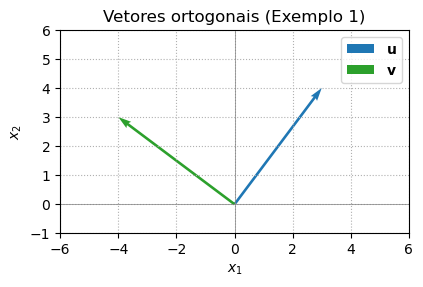

In [3]:
# Visualizar o par ortogonal: desenhamos cada vetor como uma SETA que parte da origem.
# plt.quiver(x0, y0, dx, dy) desenha uma seta começando em (x0, y0) na direção (dx, dy).
# As opções angles="xy", scale_units="xy", scale=1 fazem a seta ter o COMPRIMENTO REAL
# do vetor (sem reescala automática). Passamos as componentes uma a uma, de forma explícita.
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Seta de u (azul), da origem (0, 0) até o ponto (u[0], u[1]):
ax.quiver(0, 0, u[0], u[1], angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label=r"$\mathbf{u}$")
# Seta de v (verde), da origem até (v[0], v[1]):
ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
          color="tab:green", label=r"$\mathbf{v}$")

ax.set_xlim(-6, 6); ax.set_ylim(-1, 6)
ax.set_aspect("equal")              # mesma escala em x e y, para o ângulo reto aparecer reto
ax.grid(True, ls=":")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Vetores ortogonais (Exemplo 1)")
ax.legend(); plt.show()

## 2. Normas de vetores

$\|\mathbf{x}\|_1=\sum|x_i|$ (soma de magnitudes — ligada a esparsidade), $\|\mathbf{x}\|_2$
(comprimento) e $\|\mathbf{x}\|_\infty=\max|x_i|$ (maior componente). **Exemplo 2**:
$\mathbf{x}=(2,-1,3)^T$.

In [4]:
# Exemplo 2: três normas do mesmo vetor.
# O segundo argumento de np.linalg.norm escolhe QUAL norma calcular:
#   1      -> norma l1 (soma dos módulos)
#   2      -> norma l2 (comprimento euclidiano)
#   np.inf -> norma l_infinito (maior módulo entre as componentes)
x = np.array([2.0, -1.0, 3.0])
print("||x||_1   =", np.linalg.norm(x, 1),     "(esperado 6)")
print("||x||_2   =", np.linalg.norm(x, 2),     "(esperado sqrt(14) =", np.sqrt(14), ")")
print("||x||_inf =", np.linalg.norm(x, np.inf),"(esperado 3)")

||x||_1   = 6.0 (esperado 6)
||x||_2   = 3.7416573867739413 (esperado sqrt(14) = 3.7416573867739413 )
||x||_inf = 3.0 (esperado 3)


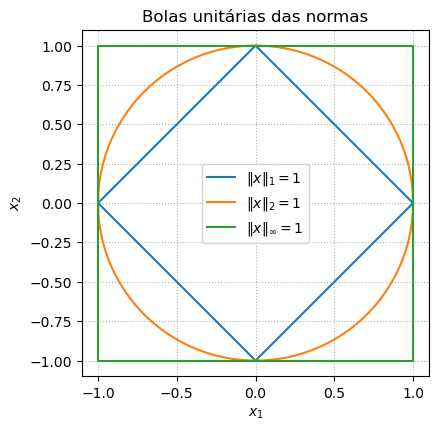

In [5]:
# A "bola unitária" de uma norma é o conjunto dos vetores com norma igual a 1.
# Desenhar as três bolas em 2D mostra, visualmente, por que as normas diferem.

# ||x||_2 = 1 é o CÍRCULO de raio 1: percorremos o ângulo th de 0 a 2*pi e
# tomamos os pontos (cos th, sin th). 'circ' tem 2 linhas (x e y) e 400 colunas (pontos).
th = np.linspace(0, 2*np.pi, 400)
circ = np.array([np.cos(th), np.sin(th)])

# ||x||_1 = 1 é um LOSANGO com vértices nos eixos: (1,0), (0,1), (-1,0), (0,-1).
# Listamos esses 4 vértices e repetimos o 1o no fim para "fechar" o contorno ao desenhar.
losango = np.array([[1, 0, -1,  0, 1],     # coordenadas x dos vértices
                    [0, 1,  0, -1, 0]])    # coordenadas y dos vértices

# ||x||_inf = 1 é um QUADRADO com lados em x=+-1 e y=+-1: cantos (1,1), (1,-1), (-1,-1), (-1,1).
quad = np.array([[1,  1, -1, -1, 1],       # coordenadas x dos cantos
                 [1, -1, -1,  1, 1]])      # coordenadas y dos cantos

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(losango[0], losango[1], label=r"$\|x\|_1=1$")   # losango[0]=linha x, losango[1]=linha y
ax.plot(circ[0], circ[1], label=r"$\|x\|_2=1$")
ax.plot(quad[0], quad[1], label=r"$\|x\|_\infty=1$")
ax.set_aspect("equal"); ax.grid(True, ls=":"); ax.legend()
ax.set_title("Bolas unitárias das normas"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.show()

## 3. Matrizes ortogonais

$Q^TQ=I$ implica $Q^{-1}=Q^T$ e $\|Q\mathbf{x}\|_2=\|\mathbf{x}\|_2$ (preserva comprimentos e
ângulos). A rotação $R(\theta)$ é o exemplo canônico (**Exemplo 3**).

In [6]:
# Exemplo 3: rotação é ortogonal e preserva norma.
# Definimos uma função que monta a matriz de rotação R(theta) das notas. Mantemos a
# 'def' porque a fórmula da matriz de rotação é justamente o objeto de estudo aqui.
def rotacao(theta):
    c, s = np.cos(theta), np.sin(theta)     # c = cos(theta), s = sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

R = rotacao(np.pi/6)   # matriz de rotação de pi/6 = 30 graus

# Ortogonal significa Q^T Q = I; np.eye(2) é a matriz identidade 2x2.
print("R^T R = I ?", np.allclose(R.T @ R, np.eye(2)))
# Para matriz ortogonal, a inversa é simplesmente a transposta:
print("R^{-1} == R^T ?", np.allclose(np.linalg.inv(R), R.T))

x = np.array([2.0, 1.0])
# Rotacionar não muda o comprimento: ||x|| e ||R x|| devem coincidir.
print("||x|| =", np.linalg.norm(x), " ||Rx|| =", np.linalg.norm(R @ x), "(iguais)")

R^T R = I ? True
R^{-1} == R^T ? True
||x|| = 2.23606797749979  ||Rx|| = 2.23606797749979 (iguais)


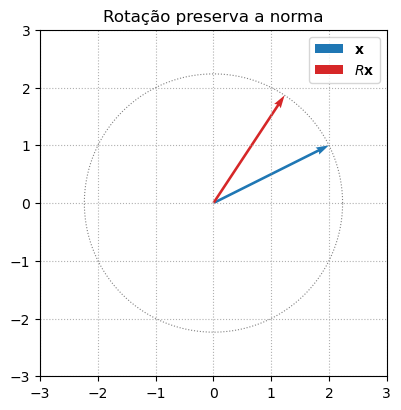

In [7]:
# Visualizar: a rotação muda a direção, não o comprimento.
x = np.array([2.0, 1.0])
Rx = R @ x                    # vetor rotacionado

fig, ax = plt.subplots(figsize=(4.5, 4.5))
# Seta de x (azul), da origem até (x[0], x[1]):
ax.quiver(0, 0, x[0], x[1], angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label=r"$\mathbf{x}$")
# Seta de R x (vermelho): mesmo comprimento, direção girada 30 graus:
ax.quiver(0, 0, Rx[0], Rx[1], angles="xy", scale_units="xy", scale=1,
          color="tab:red", label=r"$R\mathbf{x}$")

# Círculo de raio ||x||: as duas setas têm a mesma ponta sobre este círculo.
circ = np.linalg.norm(x) * np.array([np.cos(th), np.sin(th)])
ax.plot(circ[0], circ[1], "gray", ls=":", lw=0.8)

ax.set_aspect("equal"); ax.grid(True, ls=":"); ax.legend()
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_title("Rotação preserva a norma")
plt.show()

## 4. Autovalores e autovetores: direções invariantes

$A\mathbf{v}=\lambda\mathbf{v}$: ao longo de um autovetor, $A$ apenas **escala** (não desvia a
direção). Usamos $A=\begin{bmatrix}2&1\\1&2\end{bmatrix}$ (Exemplos 5/6), com $\lambda=3$
($\mathbf{v}=(1,1)$) e $\lambda=1$ ($\mathbf{v}=(1,-1)$).

In [8]:
# Autovalores e autovetores já estão prontos no NumPy: usamos np.linalg.eig diretamente.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
vals, vecs = np.linalg.eig(A)   # vals = vetor de autovalores; vecs = autovetores nas COLUNAS
print("autovalores:", vals)
print("autovetores (colunas):\n", vecs)

# Conferir a definição A v = lambda v para cada par (autovalor, autovetor).
# Atenção: o i-ésimo autovetor é a COLUNA i de vecs, acessada por vecs[:, i]
# (os dois pontos pegam todas as linhas; o i fixa a coluna).
print("A v_0 - lambda_0 v_0 =", np.round(A @ vecs[:, 0] - vals[0] * vecs[:, 0], 12))
print("A v_1 - lambda_1 v_1 =", np.round(A @ vecs[:, 1] - vals[1] * vecs[:, 1], 12))

autovalores: [3. 1.]
autovetores (colunas):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
A v_0 - lambda_0 v_0 = [0. 0.]
A v_1 - lambda_1 v_1 = [0. 0.]


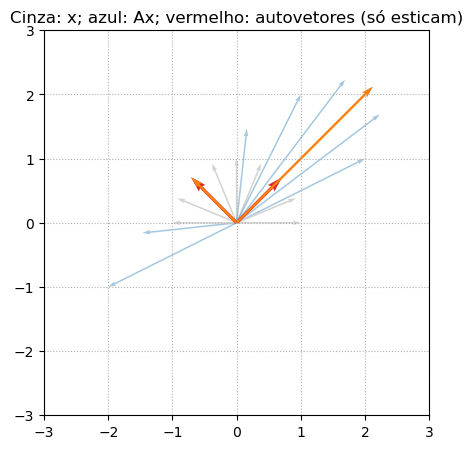

In [9]:
# Visualizar a ideia: um vetor GENÉRICO muda de direção ao ser multiplicado por A;
# um AUTOVETOR não muda de direção, só estica (A v = lambda v).

# Pequena função auxiliar só para encurtar a chamada repetida de plt.quiver
# (sempre a partir da origem, sempre com o comprimento real da seta).
def seta(ax, vetor, **kw):
    ax.quiver(0, 0, vetor[0], vetor[1],
              angles="xy", scale_units="xy", scale=1, **kw)

fig, ax = plt.subplots(figsize=(5, 5))

# (1) Vetores de teste: 9 direções unitárias espalhadas de 0 a 180 graus.
#     Para cada uma desenhamos x (cinza) e a sua imagem A x (azul).
#     Veja que A x aponta para uma direção DIFERENTE de x na maioria dos casos.
for ang in np.linspace(0, np.pi, 9):
    x = np.array([np.cos(ang), np.sin(ang)])   # vetor unitário no ângulo 'ang'
    Ax = A @ x                                  # imagem de x pela matriz A
    seta(ax, x,  color="lightgray", width=0.004)
    seta(ax, Ax, color="tab:blue", alpha=0.4, width=0.004)

# (2) Autovetores (vermelho) e suas imagens (laranja). A imagem fica na MESMA reta
#     do autovetor: só o comprimento muda (fator = autovalor). vecs[:, i] = coluna i.
for i in range(2):
    ev = vecs[:, i] / np.linalg.norm(vecs[:, i])   # autovetor normalizado (comprimento 1)
    seta(ax, ev,      color="tab:red",    width=0.008)   # autovetor
    seta(ax, A @ ev,  color="tab:orange", width=0.006)   # A vezes o autovetor (mesma direção)

ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal"); ax.grid(True, ls=":")
ax.set_title("Cinza: x; azul: Ax; vermelho: autovetores (só esticam)")
plt.show()

## 5. Cálculo via polinômio característico

Para $2\times2$, $\lambda^2-\operatorname{tr}(A)\lambda+\det(A)=0$, com
$\lambda_1+\lambda_2=\operatorname{tr}(A)$ e $\lambda_1\lambda_2=\det(A)$ (**Exemplo 6**).

In [10]:
# Relações traço/determinante e raízes do polinômio característico.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
tr = np.trace(A)            # traço = soma da diagonal
det = np.linalg.det(A)      # determinante

# Para 2x2: soma dos autovalores = traço; produto dos autovalores = determinante.
print("traço =", tr, "| soma dos autovalores =", np.sum(np.linalg.eigvals(A)))
print("det   =", det, "| produto dos autovalores =", np.prod(np.linalg.eigvals(A)))

# Os autovalores são as raízes de lambda^2 - tr*lambda + det = 0.
# np.roots recebe os COEFICIENTES do polinômio em ordem decrescente de grau:
# para lambda^2 - tr*lambda + det, os coeficientes são [1, -tr, det].
print("raízes do polinômio característico:", np.sort(np.roots([1, -tr, det])))

traço = 4.0 | soma dos autovalores = 4.0
det   = 2.9999999999999996 | produto dos autovalores = 3.0
raízes do polinômio característico: [1. 3.]


## 6. Autovalor zero, singularidade e espaço nulo

$\lambda=0$ é autovalor $\iff A$ é singular ($\operatorname{Nul}$ não trivial, posto $<n$). **Exemplo 7**:
$A=\begin{bmatrix}1&2\\2&4\end{bmatrix}$ tem $\lambda=5,0$ e $\operatorname{Nul}=\operatorname{span}\{(-2,1)\}$.

In [11]:
# Exemplo 7: autovalor zero <-> singularidade.
A = np.array([[1.0, 2.0],
              [2.0, 4.0]])
vals, vecs = np.linalg.eig(A)
print("autovalores:", np.round(vals, 12), "| posto =", np.linalg.matrix_rank(A))

# O autovetor associado ao autovalor zero gera o espaço nulo de A.
# np.abs(vals) tira o módulo de cada autovalor; np.argmin devolve a POSIÇÃO do menor
# deles -> assim localizamos qual autovalor é (numericamente) zero.
i0 = int(np.argmin(np.abs(vals)))
v0 = vecs[:, i0]                       # autovetor correspondente (coluna i0)

# Reescalar v0 dividindo pela 2a componente deixa essa componente igual a 1,
# para comparar facilmente com o (-2, 1) das notas (autovetor é único a menos de escala).
print("autovetor de lambda=0:", v0, "-> normalizado p/ 2a comp:", v0 / v0[1])
print("A v0 ~ 0 ?", np.allclose(A @ v0, 0.0))

autovalores: [0. 5.] | posto = 1
autovetor de lambda=0: [-0.89442719  0.4472136 ] -> normalizado p/ 2a comp: [-2.  1.]
A v0 ~ 0 ? True


## 7. Diagonalização e potências

Com $n$ autovetores LI, $A=V\Lambda V^{-1}$ e $A^k=V\Lambda^kV^{-1}$ — o que torna potências
baratas e revela o papel dos autovalores no longo prazo (Exemplo 8).

In [12]:
# Diagonalização A = V L V^{-1} e potências A^k = V L^k V^{-1}.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
vals, V = np.linalg.eig(A)    # V tem os autovetores nas colunas
L = np.diag(vals)             # np.diag transforma o vetor de autovalores na matriz diagonal Lambda

# Reconstruir A a partir da diagonalização (np.linalg.inv calcula a inversa de V):
print("A = V L V^{-1} ?", np.allclose(A, V @ L @ np.linalg.inv(V)))

# Potência A^k fica barata: basta elevar os autovalores a k (Lambda^k = diag(lambda_i^k)).
k = 5
Ak_via_diag = V @ np.diag(vals**k) @ np.linalg.inv(V)   # vals**k eleva CADA autovalor a k
# np.linalg.matrix_power(A, k) calcula A @ A @ ... @ A (k vezes) diretamente, para comparar:
print("A^k (diagonalização) == np.linalg.matrix_power(A, k) ?",
      np.allclose(Ak_via_diag, np.linalg.matrix_power(A, k)))

A = V L V^{-1} ? True
A^k (diagonalização) == np.linalg.matrix_power(A, k) ? True


## 8. Matriz defeituosa (não diagonalizável)

$A=\begin{bmatrix}3&1\\0&3\end{bmatrix}$ tem um único autovalor $3$ e **uma só** direção de
autovetores: faltam autovetores para formar uma base, e $V$ fica (numericamente) singular.

In [13]:
# Matriz defeituosa: tem um só autovalor e uma só direção de autovetores,
# então faltam autovetores para formar uma base e V fica (quase) não invertível.
A = np.array([[3.0, 1.0],
              [0.0, 3.0]])
vals, V = np.linalg.eig(A)
print("autovalores:", vals)
print("autovetores (colunas):\n", np.round(V, 6))   # as duas colunas saem praticamente iguais

# np.linalg.cond(V) é o "número de condição": quanto maior, mais perto V está de ser
# singular (não invertível). Um valor enorme avisa que a diagonalização não é confiável.
print("número de condição de V:", np.linalg.cond(V), "(enorme -> quase não invertível)")
print("=> a diagonalização não é confiável; a matriz é defeituosa.")

autovalores: [3. 3.]
autovetores (colunas):
 [[ 1. -1.]
 [ 0.  0.]]
número de condição de V: 3002399751580330.0 (enorme -> quase não invertível)
=> a diagonalização não é confiável; a matriz é defeituosa.


## 9. Matrizes simétricas e decomposição espectral

Se $A=A^T$, o teorema espectral garante $A=Q\Lambda Q^T$ com $Q$ ortogonal e autovalores reais,
e $A=\sum_i\lambda_i\mathbf{q}_i\mathbf{q}_i^T$ (soma de posto 1). Usamos `np.linalg.eigh`, que
é o método correto para simétricas (retorna base ortonormal e autovalores reais).

In [14]:
# Exemplo 9: decomposição espectral de uma matriz simétrica A = Q L Q^T.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
# Para matrizes SIMÉTRICAS usa-se np.linalg.eigh (não np.linalg.eig): ela devolve
# autovalores reais já ordenados e uma base de autovetores ortonormal (Q ortogonal).
vals, Q = np.linalg.eigh(A)
L = np.diag(vals)                  # matriz diagonal Lambda com os autovalores

print("Q ortogonal (Q^T Q = I)?", np.allclose(Q.T @ Q, np.eye(2)))
print("A = Q L Q^T ?", np.allclose(A, Q @ L @ Q.T))

# Forma alternativa: A = soma_i lambda_i * (q_i q_i^T), uma soma de matrizes de posto 1.
# np.outer(q_i, q_i) é o produto externo q_i q_i^T (uma matriz). Somamos as duas parcelas:
parcela_0 = vals[0] * np.outer(Q[:, 0], Q[:, 0])   # lambda_0 * q_0 q_0^T
parcela_1 = vals[1] * np.outer(Q[:, 1], Q[:, 1])   # lambda_1 * q_1 q_1^T
recon = parcela_0 + parcela_1
print("A = sum lambda_i q_i q_i^T ?", np.allclose(A, recon))

Q ortogonal (Q^T Q = I)? True
A = Q L Q^T ? True
A = sum lambda_i q_i q_i^T ? True


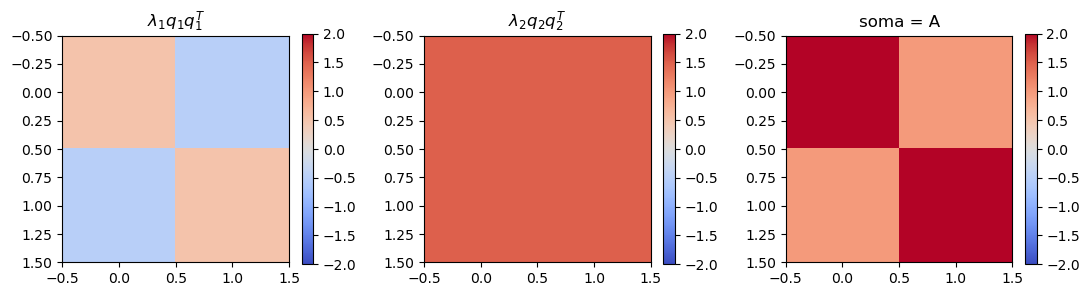

In [15]:
# Visualizar como mapa de calor cada parcela de posto 1 e a soma das duas (= A).
# Reusamos parcela_0 e parcela_1 calculadas na célula anterior.
soma = parcela_0 + parcela_1     # deve reproduzir A

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))   # três painéis lado a lado

# imshow desenha a matriz como mapa de calor; vmin/vmax fixam a escala de cor nos 3 painéis.
im0 = axes[0].imshow(parcela_0, cmap="coolwarm", vmin=-2, vmax=2)
axes[0].set_title(r"$\lambda_1 q_1 q_1^T$")
fig.colorbar(im0, ax=axes[0], fraction=0.046)       # barra de cores do painel 0

im1 = axes[1].imshow(parcela_1, cmap="coolwarm", vmin=-2, vmax=2)
axes[1].set_title(r"$\lambda_2 q_2 q_2^T$")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(soma, cmap="coolwarm", vmin=-2, vmax=2)
axes[2].set_title("soma = A")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout(); plt.show()

## 10. Interpretação geométrica: círculo $\to$ elipse

Para $A$ simétrica, $A=Q\Lambda Q^T$ leva o **círculo unitário** numa **elipse** cujos eixos
apontam ao longo dos autovetores e cujos semieixos têm comprimento $|\lambda_i|$.

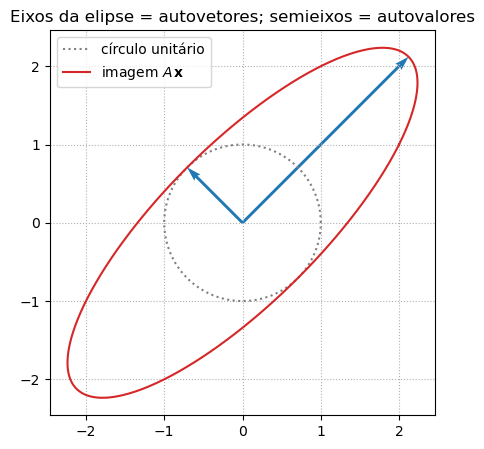

In [16]:
# A imagem do círculo unitário sob A (simétrica) é uma elipse alinhada aos autovetores.
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
vals, Q = np.linalg.eigh(A)        # autovalores reais ordenados e Q ortogonal (caso simétrico)

# Pontos do círculo unitário: 'circ' tem 2 linhas (x, y) e 400 colunas (um ponto por coluna).
th = np.linspace(0, 2*np.pi, 400)
circ = np.array([np.cos(th), np.sin(th)])

# A @ circ aplica a matriz A a TODOS os pontos de uma vez (cada coluna vira A vezes aquele ponto).
# O resultado é a elipse.
elipse = A @ circ

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(circ[0], circ[1], "gray", ls=":", label="círculo unitário")
ax.plot(elipse[0], elipse[1], "tab:red", label="imagem $A\\,\\mathbf{x}$")

# Eixos principais da elipse = autovetores esticados pelo autovalor (semieixo = |lambda_i|).
# Q[:, i] é o i-ésimo autovetor (coluna i); multiplicamos por vals[i] para obter o eixo.
for i in range(2):
    eixo = Q[:, i] * vals[i]
    ax.quiver(0, 0, eixo[0], eixo[1],
              angles="xy", scale_units="xy", scale=1, color="tab:blue")

ax.set_aspect("equal"); ax.grid(True, ls=":"); ax.legend()
ax.set_title("Eixos da elipse = autovetores; semieixos = autovalores")
plt.show()

## 11. Norma de Frobenius

$\|A\|_F=\sqrt{\sum_{ij}a_{ij}^2}=\sqrt{\operatorname{tr}(A^TA)}$ mede o tamanho global da
matriz (útil para erro de aproximação). **Exemplo 10**: $\|A\|_F=\sqrt{15}$.

In [17]:
# Exemplo 10: norma de Frobenius calculada de três formas equivalentes.
A = np.array([[1.0, 2.0, 0.0],
              [0.0, -1.0, 3.0]])

# Forma pronta: o argumento "fro" pede a norma de Frobenius diretamente.
print("||A||_F (np)            =", np.linalg.norm(A, "fro"))
# Pela definição: raiz da soma de todos os a_ij ao quadrado.
# A**2 eleva CADA entrada ao quadrado; np.sum soma todas as entradas.
print("sqrt(sum a_ij^2)        =", np.sqrt(np.sum(A**2)))
# Forma equivalente com o traço: ||A||_F = sqrt(trace(A^T A)).
print("sqrt(trace(A^T A))      =", np.sqrt(np.trace(A.T @ A)), "(esperado sqrt(15) =", np.sqrt(15), ")")

||A||_F (np)            = 3.872983346207417
sqrt(sum a_ij^2)        = 3.872983346207417
sqrt(trace(A^T A))      = 3.872983346207417 (esperado sqrt(15) = 3.872983346207417 )


## 12. Norma espectral

$\|A\|_2=\max_{\|\mathbf{x}\|=1}\|A\mathbf{x}\|_2=\sqrt{\lambda_{\max}(A^TA)}$ é o maior fator de
amplificação. **Exemplo 12** (cisalhamento): $\|A\|_2=1+\sqrt2$. Esse $\sqrt{\lambda_{\max}(A^TA)}$
é o maior **valor singular** $\sigma_1$ (ponte para a Aula 4).

In [18]:
# Exemplo 12: norma espectral do cisalhamento, via ||A||_2 = sqrt(lambda_max(A^T A)).
A = np.array([[1.0, 2.0],
              [0.0, 1.0]])

# A^T A é sempre simétrica, então usamos np.linalg.eigvalsh (versão para simétricas que
# devolve só os autovalores, reais e ordenados). np.max pega o maior deles.
lam_max = np.max(np.linalg.eigvalsh(A.T @ A))
print("lambda_max(A^T A) =", lam_max, "(esperado 3+2*sqrt(2) =", 3 + 2*np.sqrt(2), ")")
print("||A||_2 = sqrt(lambda_max) =", np.sqrt(lam_max), "(esperado 1+sqrt(2) =", 1 + np.sqrt(2), ")")

# Conferência: np.linalg.norm(A, 2) já calcula a norma espectral diretamente.
print("conferência np.linalg.norm(A, 2) =", np.linalg.norm(A, 2))

lambda_max(A^T A) = 5.82842712474619 (esperado 3+2*sqrt(2) = 5.82842712474619 )
||A||_2 = sqrt(lambda_max) = 2.414213562373095 (esperado 1+sqrt(2) = 2.414213562373095 )
conferência np.linalg.norm(A, 2) = 2.414213562373095


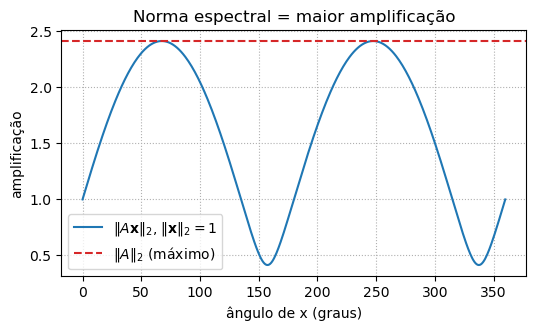

In [19]:
# A norma espectral é o PICO de ||A x|| quando x percorre todas as direções unitárias.
th = np.linspace(0, 2*np.pi, 400)

# Montamos os vetores unitários (cos th, sin th): 2 linhas, 400 colunas (um vetor por coluna).
direcoes = np.array([np.cos(th), np.sin(th)])

# A @ direcoes aplica A a todos os 400 vetores de uma vez (cada coluna é um A x).
# np.linalg.norm(..., axis=0) calcula a norma ao longo do eixo das LINHAS (axis=0),
# ou seja, o comprimento de cada coluna -> um vetor com os 400 valores de ||A x||.
amp = np.linalg.norm(A @ direcoes, axis=0)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.degrees(th), amp, label=r"$\|A\mathbf{x}\|_2$, $\|\mathbf{x}\|_2=1$")
# A linha vermelha marca o máximo teórico, que é exatamente a norma espectral ||A||_2.
ax.axhline(np.linalg.norm(A, 2), color="tab:red", ls="--", label=r"$\|A\|_2$ (máximo)")
ax.set_xlabel("ângulo de x (graus)"); ax.set_ylabel("amplificação"); ax.legend()
ax.grid(True, ls=":"); ax.set_title("Norma espectral = maior amplificação")
plt.show()

## 13. Exercício 5 (verificação em Python pedida nas notas)

$A=\begin{bmatrix}2&0\\0&1\\0&0\end{bmatrix}$: calcular $A^TA$, seus autovalores, $\|A\|_2$ e
$\|A\|_F$.

In [20]:
# Exercício 5: A é 3x2 (3 linhas, 2 colunas).
A = np.array([[2.0, 0.0],
              [0.0, 1.0],
              [0.0, 0.0]])
AtA = A.T @ A                       # A^T A: matriz 2x2 simétrica
print("A^T A =\n", AtA)
# eigvalsh: autovalores de uma matriz simétrica (reais e ordenados).
print("autovalores de A^T A:", np.linalg.eigvalsh(AtA), "(esperado 1 e 4)")
print("||A||_2 =", np.linalg.norm(A, 2), "(esperado 2)")            # norma espectral
print("||A||_F =", np.linalg.norm(A, "fro"), "(esperado sqrt(5) =", np.sqrt(5), ")")  # Frobenius

A^T A =
 [[4. 0.]
 [0. 1.]]
autovalores de A^T A: [1. 4.] (esperado 1 e 4)
||A||_2 = 2.0 (esperado 2)
||A||_F = 2.23606797749979 (esperado sqrt(5) = 2.23606797749979 )


## Síntese da aula

- **Autovetores** são direções invariantes; **autovalores** são os fatores de escala. A
  **diagonalização** $A=V\Lambda V^{-1}$ desacopla essas direções; no caso **simétrico**, a
  base fica ortonormal e $A=Q\Lambda Q^T=\sum_i\lambda_i\mathbf{q}_i\mathbf{q}_i^T$.
- $\lambda=0$ sinaliza **singularidade**; matrizes **defeituosas** não são diagonalizáveis.
- As **normas** de Frobenius e espectral medem tamanho e máxima amplificação, com
  $\|A\|_2=\sqrt{\lambda_{\max}(A^TA)}=\sigma_1$.

## Limitações a discutir

- `np.linalg.eig` pode devolver valores **complexos** (ex.: rotação pura) e **não** ordena os
  autovalores; para matrizes simétricas use `eigh`/`eigvalsh` (real e ordenado).
- O **sinal/escala** de um autovetor é arbitrário — o que importa é a direção.
- Para matrizes **defeituosas**, a diagonalização falha numericamente (matriz $V$ mal-condicionada).

## Experimentos sugeridos

1. Varie $\theta$ na rotação e confirme $\|R\mathbf{x}\|=\|\mathbf{x}\|$.
2. Tome uma matriz **não simétrica** com autovalores reais e compare `eig` com a diagonalização.
3. Aumente $k$ nas potências $A^k$ e observe a dominância do maior $|\lambda|$.
4. Gere uma simétrica $3\times3$ aleatória e verifique $A=Q\Lambda Q^T$ e a soma de posto 1.
5. Confira o Exercício 4 das notas: $Q=\frac{1}{\sqrt5}\begin{bmatrix}1&-2\\2&1\end{bmatrix}$
   é ortogonal e preserva a norma de $(3,-1)$.

*Próxima aula (Aula 4): a SVD $A=U\Sigma V^T$ generaliza a decomposição espectral para matrizes
retangulares, com $\sigma_i=\sqrt{\lambda_i(A^TA)}$.*